# GUS01D: GeoTERYT Geometry Assignment Methods

This notebook demonstrates the geometry assignment methods in GeoTERYT database v3.1.

## Overview
- Load complete database from GUS01C
- Demonstrate geometry assignment workflow:
  1. `assign_geometries()` - exact match for same-year teryt_ids
  2. `assign_missing_geometries()` - find geometries for unchanged units
  3. `impute_geometries_past_tid()` - use historical codes for imputation
  4. `impute_from_best_candidates()` - apply best geometry candidates
  5. `country_shape_check()` - verify coverage against Poland boundary

In [1]:
import os
import sys
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import gc

# Change root directory to the repo root
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
            return p
    return start

repo_root = find_repo_root()
geospatial_root = repo_root.parent.parent / 'Data' / 'Geospatial'

os.chdir(repo_root)
if str(repo_root / 'Code' / 'tools') not in sys.path:
    sys.path.append(str(repo_root / 'Code' / 'tools'))

# Import local toolkit
import geoTERYT_db as gtdb
importlib.reload(gtdb)

print(f"Repo root: {repo_root}")
print(f"geoTERYT_db version: {gtdb.__doc__.split(chr(10))[0] if gtdb.__doc__ else 'unknown'}")

Repo root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper
geoTERYT_db version: 


## 1. Load the Complete Database

Load the database saved from GUS01C (includes harmonized data + stored geometries).

In [2]:
# Load complete database
complete_db_path = geospatial_root / 'geoteryt_complete.pkl'
db = gtdb.load_complete_database(complete_db_path)

# Print summary
db.print_summary()

Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete.pkl...
  Database version: 3.1
  ✓ Restored geometry data for years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  ✓ Loaded 4560 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 0
GeoTERYT Database Summary (v3.0)
Total records:           4,560
Year range:              1999 - 2024
------------------------------------------------------------
Administrative levels:
  Voivodeships (2):      16
  Powiats (5):           382
  Gminas (6):            4162
------------------------------------------------------------
Change tracking:
  Records with changes:      773
  Records with level changes: 0
  Records with kind changes:  0
------------------------------------------------------------
Geometry:
  Records with geometry: 0
  Geometry years:        [2005, 2006,

## 2. Check Initial Geometry Status

Before assignment, check how many records have geometries.

In [3]:
# Check geometry status for different years
years_to_check = [1999, 2005, 2010, 2015, 2020, 2024]

for year in years_to_check:
    snapshot = db.get_snapshot(year)
    gminas = [r for r in snapshot if r.level == 6 and r.rodz not in ['4', '5', '8', '9']]
    with_geom = sum(1 for r in gminas if r.has_geometry)
    print(f"{year}: {with_geom}/{len(gminas)} gminas with geometry ({with_geom/len(gminas)*100:.1f}%)")

1999: 0/2489 gminas with geometry (0.0%)
2005: 0/2478 gminas with geometry (0.0%)
2010: 0/2479 gminas with geometry (0.0%)
2015: 0/2478 gminas with geometry (0.0%)
2020: 0/2477 gminas with geometry (0.0%)
2024: 0/2477 gminas with geometry (0.0%)


In [4]:
# Check which geometry years are available
print(f"Geometry years available: {sorted(db._geometries.keys())}")
for year, gdf in sorted(db._geometries.items()):
    print(f"  {year}: {len(gdf)} geometries")

Geometry years available: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  2005: 2477 geometries
  2006: 2478 geometries
  2007: 2478 geometries
  2008: 2478 geometries
  2009: 2478 geometries
  2010: 2479 geometries
  2011: 2479 geometries
  2012: 2479 geometries
  2015: 2481 geometries
  2016: 2481 geometries
  2017: 2478 geometries
  2018: 2478 geometries
  2021: 2477 geometries
  2022: 2477 geometries
  2023: 2477 geometries


## 3. Assign Geometries - Exact Match

Use `assign_geometries(year, level)` to assign geometries where teryt_id matches exactly.

In [5]:
# Assign geometries for year 1999 (the oldest)
result = db.assign_geometries(year=1999, level=6, verbose=True)

  No geometry data available for year 1999


In [6]:
# Assign for other available years
'''
for year in sorted(db._geometries.keys(), reverse=True):
    print(f"\n=== Year {year} ===")
    result = db.assign_geometries(year=year, level=6, verbose=True)
'''


'\nfor year in sorted(db._geometries.keys(), reverse=True):\n    print(f"\n=== Year {year} ===")\n    result = db.assign_geometries(year=year, level=6, verbose=True)\n'

## 4. Assign Missing Geometries - Cross-Year Matching

For units without geometry that haven't changed, find matching geometries from other years.

In [7]:
# Try to find geometries for 1999 units that are missing
result = db.assign_missing_geometries(year=1999, level=6, tolerance=0.5, verbose=True)

Finding missing geometries for year 1999 (tolerance=50.0%)...
  Units without geometry: 3649
  Found candidate for 1605023 from year 2005 for 1605023.
  Found candidate for 0601132 from year 2005 for 0601132.
  Found candidate for 2415031 from year 2005 for 2415031.
  Found candidate for 1206124 from year 2005 for 1206124.
  Found candidate for 1010094 from year 2005 for 1010094.
  Found candidate for 3002075 from year 2005 for 3002075.
  Found candidate for 1807062 from year 2005 for 1807062.
  Found candidate for 2413072 from year 2005 for 2413072.
  Found candidate for 1425122 from year 2005 for 1425122.
  Found candidate for 2806102 from year 2005 for 2806102.
  Found candidate for 3007102 from year 2005 for 3007102.
  Found candidate for 0208103 from year 2005 for 0208103.
  Found candidate for 0601152 from year 2005 for 0601152.
  Found candidate for 1817073 from year 2005 for 1817073.
  Found candidate for 1209015 from year 2005 for 1209015.
  Found candidate for 2005092 from ye

In [9]:
# Check status after assignment
year = 1999
snapshot = db.get_snapshot(year)
gminas = [r for r in snapshot if r.level == 6 and r.rodz not in ['4', '5', '8', '9']]
with_geom = sum(1 for r in gminas if r.has_geometry)
print(f"{year}: {with_geom}/{len(gminas)} gminas with geometry ({with_geom/len(gminas)*100:.1f}%)")

# Show some that are still missing
missing = [r for r in gminas if not r.has_geometry][:5]
print(f"\nSample missing gminas:")
for r in missing:
    print(f"  {r.teryt_id} - {r.name} (has_changes={r.has_changes}, historical_codes={r.historical_codes[:3] if r.historical_codes else []}...)")

1999: 2278/2489 gminas with geometry (91.5%)

Sample missing gminas:
  1006102 - Rzgów (has_changes=True, historical_codes=['1006102', '1006103']...)
  1420112 - Sochocin (has_changes=True, historical_codes=['1420112', '1420113']...)
  1423042 - Odrzywół (has_changes=True, historical_codes=['1423042', '1423043']...)
  0804072 - Otyń (has_changes=True, historical_codes=['0804072', '0804073']...)
  2211021 - Jastarnia (has_changes=True, historical_codes=['2211021', '2211023']...)


In [10]:
print(db._geometries[2005][db._geometries[2005]['teryt_id'] == '0202031'])
pd.DataFrame(db._geometries[2005])

       obszar     nazwa    teryt teryt_id  \
8  1002020310  Pieszyce  0202031  0202031   

                                            geometry  
8  POLYGON ((331106.008 322110.444, 331106.757 32...  


,obszar,nazwa,teryt,teryt_id,geometry
0,1002010110,BolesÅawiec (gm. miejska),0201011,0201011,"POLYGON ((257780.16 384378.444, 257817.699 384..."
1,1002010220,BolesÅawiec,0201022,0201022,"POLYGON ((265099.214 404717.186, 265154.691 40..."
2,1002010320,Gromadka,0201032,0201032,"POLYGON ((272862.49 410731.901, 272865.944 410..."
3,1002010440,Nowogrodziec - miasto,0201043,0201043,"POLYGON ((251843.881 376898.196, 251869.507 37..."
4,1002010520,Osiecznica,0201052,0201052,"POLYGON ((263397.904 405978.203, 263417.835 40..."
...,...,...,...,...,...
2472,1032180440,Resko - miasto,3218043,3218043,"POLYGON ((272035.587 673230.884, 272032.066 67..."
2473,1032180540,WÄgorzyno - miasto,3218053,3218053,"POLYGON ((270956.132 642263.771, 270959.685 64..."
2474,1032610110,M. Koszalin,3261011,3261011,"POLYGON ((323845.212 709532.461, 323899.111 70..."
2475,1032620110,M. Szczecin,3262011,3262011,"POLYGON ((205545.334 638954.175, 205563.144 63..."


## 5. Impute Using Historical Codes

For units with changes, use `code_by_year` to find affiliated teryt_ids and search for geometry candidates.

In [11]:
# Check a unit with historical codes
sample = None
for r in db._records.values():
    if r.historical_codes and len(r.historical_codes) > 1 and r.level == 6:
        sample = r
        break

if sample:
    print(f"Sample unit: {sample.teryt_id} - {sample.name}")
    print(f"  historical_codes: {sample.historical_codes}")
    print(f"  code_by_year: {sample.code_by_year}")
    print(f"  has_geometry: {sample.has_geometry}")

Sample unit: 0202031 - Pieszyce
  historical_codes: ['0202031', '0202033']
  code_by_year: {1999: '0202031', 2000: '0202031', 2001: '0202031', 2002: '0202031', 2003: '0202031', 2004: '0202031', 2005: '0202031', 2006: '0202031', 2007: '0202031', 2008: '0202031', 2009: '0202031', 2010: '0202031', 2011: '0202031', 2012: '0202031', 2013: '0202031', 2014: '0202031', 2015: '0202031', 2016: '0202033', 2017: '0202033', 2018: '0202033', 2019: '0202033', 2020: '0202033', 2021: '0202033', 2022: '0202033', 2023: '0202033', 2024: '0202033'}
  has_geometry: False


In [12]:
# Impute geometries using historical codes
result = db.impute_geometries_past_tid(year=1999, level=6, verbose=True)

Imputing geometries using past teryt_ids for year 1999...
  Units without geometry: 268
  ✓ Candidates found: 200
  ✓ Directly imputed: 0
  Remaining without geometry: 268


In [13]:
# Apply best candidates
result = db.impute_from_best_candidates(verbose=True)

Imputing geometries from best candidates...
  ✓ Imputed: 200


105

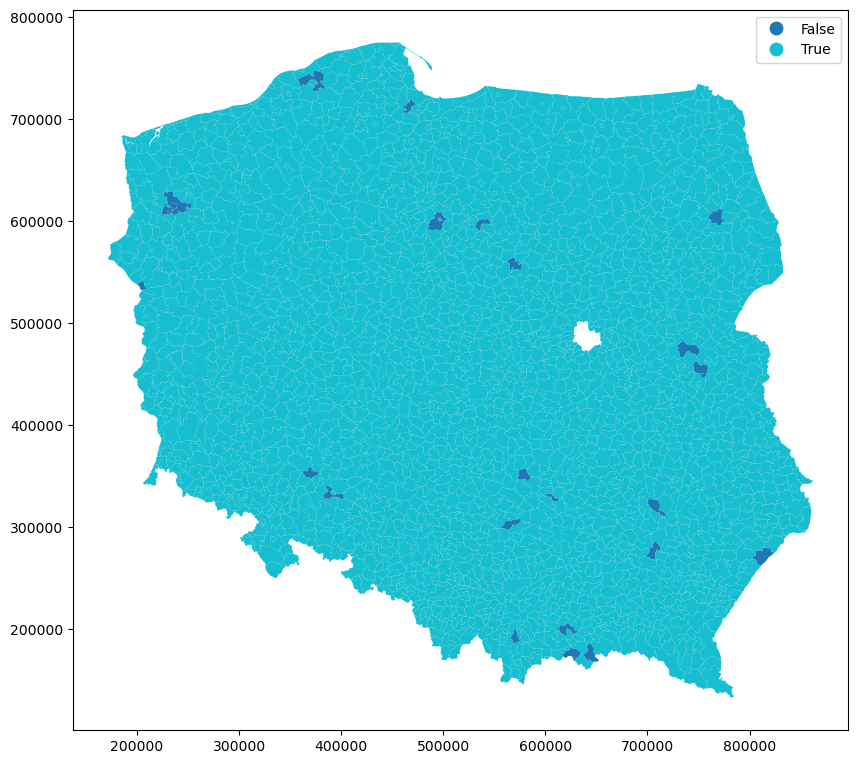

In [14]:
test = db.to_geodataframe(year=1999, level=6)
test.plot(column='has_geometry', figsize=(10, 10), legend=True)
gc.collect()

## 6. Country Shape Check

Verify geometry coverage by overlaying with Poland boundary.

In [ ]:
# Check coverage for different years
'''
for year in [1999, 2010, 2020, 2024]:
    print(f"\n=== Year {year} ===")
    result = db.country_shape_check(year=year, level=6, verbose=True)
'''
result = db.country_shape_check(year=1999, level=6, verbose=True)

## 7. Visualize Coverage

In [ ]:
# Visualize coverage for a specific year
year = 1999

gdf = db.to_geodataframe(year=year, level=6, exclude_subdivisions=True, only_with_geometry=True)
poland = db.get_poland_boundary()

fig, ax = plt.subplots(1, 1, figsize=(12, 12), dpi = 300)

# Plot Poland boundary first (as background)
if poland is not None:
    gpd.GeoSeries([poland]).plot(ax=ax, color='lightcoral', alpha=0.5, label='Missing')

# Plot gminas with geometry
gdf.plot(ax=ax, facecolor='lightgreen', edgecolor='darkgreen', linewidth=0.1, alpha=0.5)

ax.set_title(f'Geometry Coverage for Year {year} ({len(gdf)} gminas with geometry)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# Show gminas missing geometry (if any) with geometry_notes
year = 1999
snapshot = db.get_snapshot(year)
gminas = [r for r in snapshot if r.level == 6 and r.rodz not in ['4', '5', '8', '9']]
missing = [r for r in gminas if not r.has_geometry]

print(f"Gminas missing geometry in {year}: {len(missing)}")
if missing:
    for r in missing:
        print(f"  {r.teryt_id} - {r.name} (notes: {r.geometry_notes})")

## 8. Save Updated Database

Save the database with assigned geometries.

In [ ]:
# Save the updated database
output_path = geospatial_root / 'geoteryt_complete_v31.pkl'
db.save_complete(output_path, verbose=True)

## Summary

The geometry assignment workflow in v3.1:

1. **`load_geometries()`** - Stores geometry files in `_geometries` dict (from GUS01C)
2. **`assign_geometries(year, level)`** - Assigns geometry where teryt_id matches exactly
3. **`assign_missing_geometries(year, level)`** - For unchanged units, finds geometry from other years
4. **`impute_geometries_past_tid(year, level)`** - Uses `code_by_year` to find affiliated teryt_ids
5. **`impute_from_best_candidates()`** - Applies geometry_best_candidate to records
6. **`country_shape_check(year, level)`** - Verifies coverage against Poland boundary

Key advantages:
- Explicit control over geometry assignment
- Clear tracking via `geometry_notes`
- Better handling of units with ID changes
- Verification against national boundary